# Week 5: Comprehensive Data Science Project

## E-Commerce Sales Analytics:
## From Data Visualization to Statistical Analysis and Machine Learning

### Internship Project

This project integrates the analytical skills developed during Weeks 2, 3, and 4 into a complete end-to-end data science workflow.

### Project Stages

1. Data Preparation
2. Exploratory Data Analysis
3. Data Visualization
4. Statistical Analysis
5. Machine Learning
6. Model Evaluation
7. Business Insights
8. Strategic Recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


# Load Dataset

In [2]:
file_path = "../Week-2-Advanced-Data-Visualization/ecommerce_sales_analytics_5000.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (5000, 12)


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


# Basic Dataset Information

In [3]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

DATASET INFORMATION

Shape:
(5000, 12)

Columns:
['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']

Data Types:
order_id              int64
order_date              str
customer_id           int64
product_category        str
region                  str
quantity              int64
unit_price          float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

Missing Values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate Rows:
0


# Data Cleaning

In [4]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

df = df.dropna(
    subset=["revenue"]
)

df = df.drop_duplicates()

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (5000, 12)


# Feature Engineering

In [5]:
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_dayofweek"] = df["order_date"].dt.dayofweek

print("Feature engineering completed!")

display(
    df[
        [
            "order_date",
            "order_year",
            "order_month",
            "order_day",
            "order_dayofweek"
        ]
    ].head()
)

Feature engineering completed!


,order_date,order_year,order_month,order_day,order_dayofweek
0,2022-01-01,2022,1,1,5
1,2022-01-02,2022,1,2,6
2,2022-01-03,2022,1,3,0
3,2022-01-04,2022,1,4,1
4,2022-01-05,2022,1,5,2


# PART A — BUSINESS OVERVIEW

## Key Business Metrics

In [6]:
total_revenue = df["revenue"].sum()

average_revenue = df["revenue"].mean()

total_orders = len(df)

total_customers = df["customer_id"].nunique()

average_rating = df["customer_rating"].mean()

average_discount = df["discount"].mean()

print("=" * 55)
print("KEY BUSINESS METRICS")
print("=" * 55)

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Revenue per Order: {average_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {total_customers:,}")
print(f"Average Customer Rating: {average_rating:.2f}")
print(f"Average Discount: {average_discount:.2%}")

KEY BUSINESS METRICS
Total Revenue: 5,109,775.74
Average Revenue per Order: 1,021.96
Total Orders: 5,000
Unique Customers: 989
Average Customer Rating: 2.97
Average Discount: 18.00%


## Top Category and Region

In [7]:
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top Product Category:")
print(category_revenue.idxmax())

print("\nTop Region:")
print(region_revenue.idxmax())

Top Product Category:
Electronics

Top Region:
West


# PART B — WEEK 2 VISUALIZATION

## Category Revenue

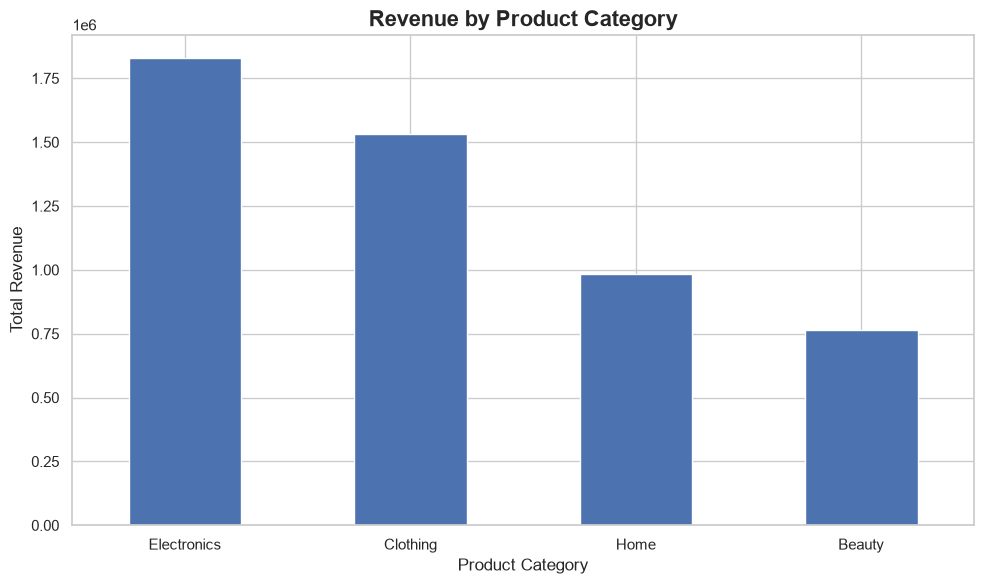

In [8]:
plt.figure(figsize=(10, 6))

category_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue by Product Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Region Revenue

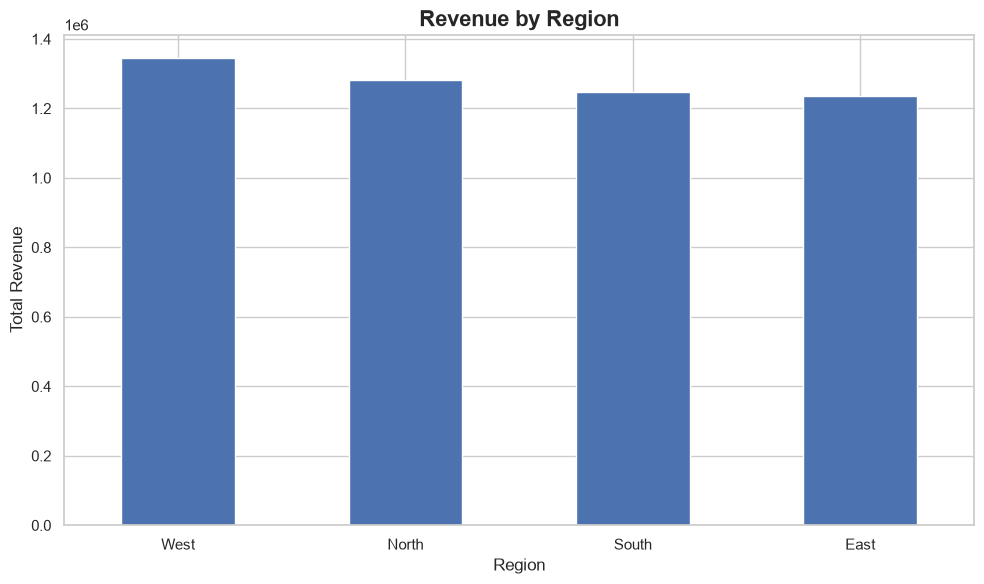

In [9]:
plt.figure(figsize=(10, 6))

region_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Discount vs Revenue

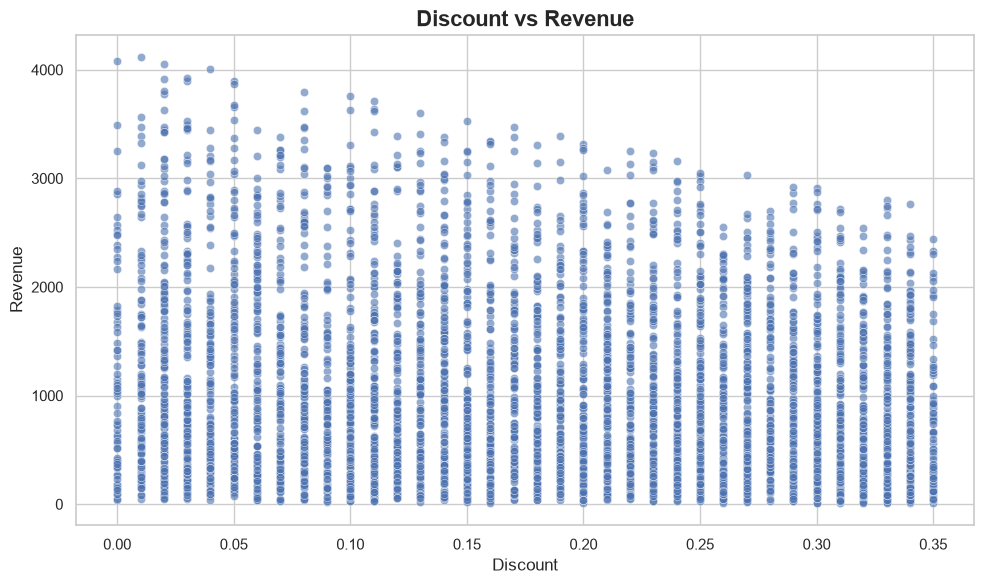

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="discount",
    y="revenue",
    alpha=0.6
)

plt.title(
    "Discount vs Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Rating vs Revenue

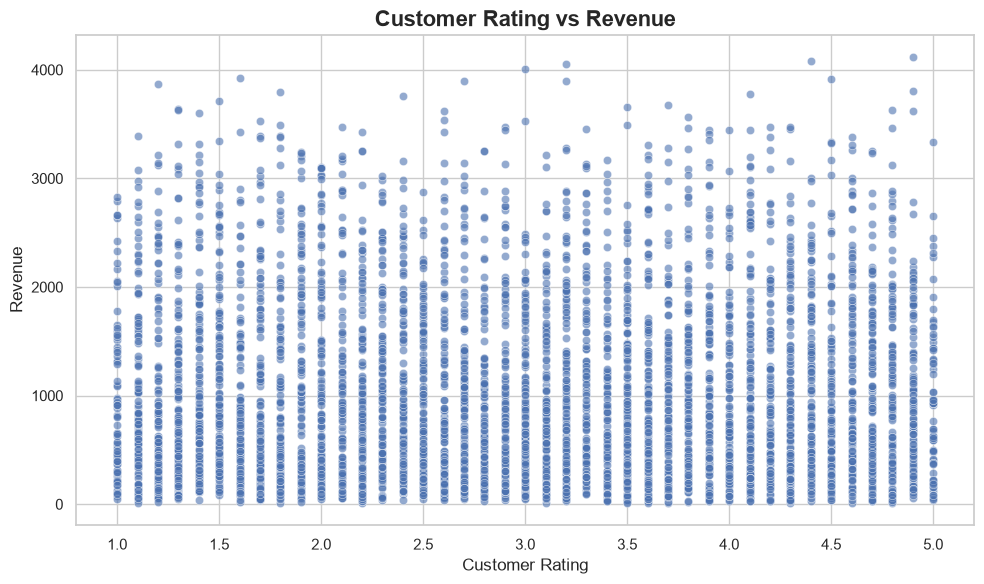

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="customer_rating",
    y="revenue",
    alpha=0.6
)

plt.title(
    "Customer Rating vs Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Rating")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Monthly Revenue

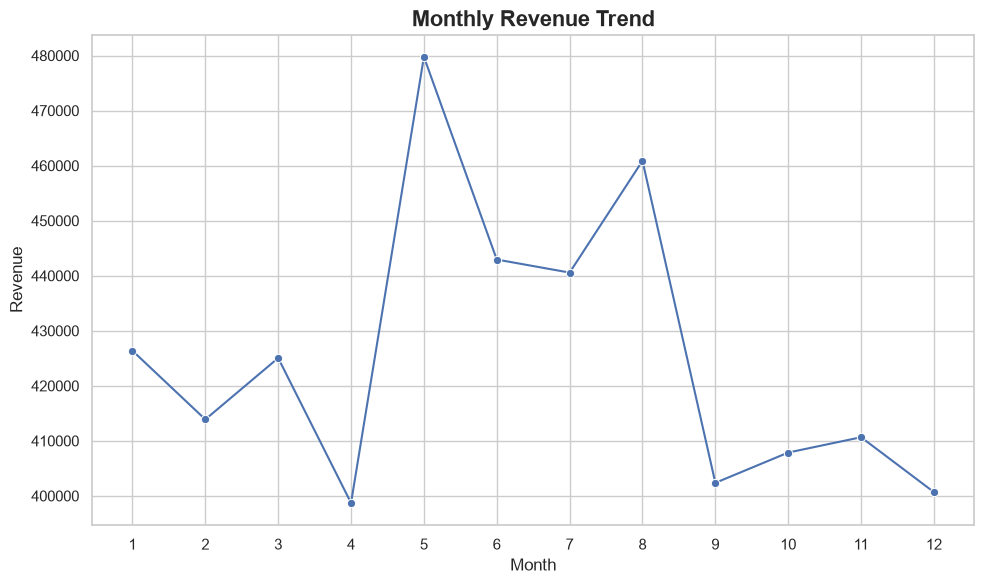

In [12]:

monthly_revenue = (
    df.groupby("order_month")["revenue"]
    .sum()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker="o"
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Monthly Revenue Heatmap

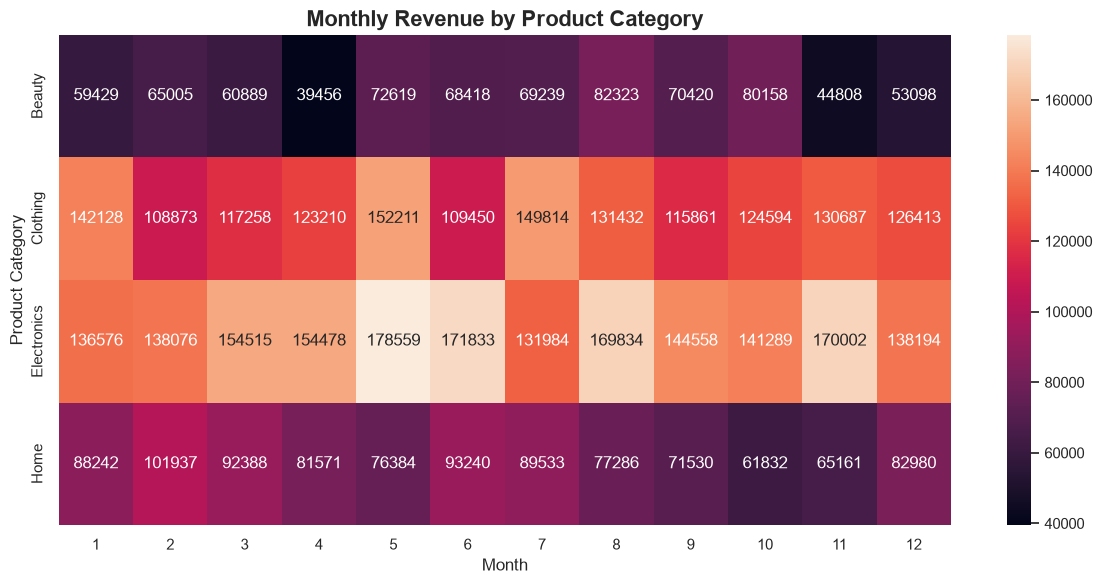

In [13]:
monthly_category = pd.pivot_table(
    df,
    values="revenue",
    index="product_category",
    columns="order_month",
    aggfunc="sum"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    monthly_category,
    annot=True,
    fmt=".0f"
)

plt.title(
    "Monthly Revenue by Product Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

# PART C — WEEK 3 STATISTICAL ANALYSIS

## Descriptive Statistics

In [14]:
print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)

display(
    df[
        [
            "quantity",
            "unit_price",
            "discount",
            "delivery_days",
            "customer_rating",
            "revenue"
        ]
    ].describe()
)

DESCRIPTIVE STATISTICS


,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


## ANOVA

H0: Mean revenue is equal across product categories.

H1: At least one category has a different mean revenue.

In [15]:
groups = []

categories = df["product_category"].unique()

for category in categories:

    group = df[
        df["product_category"] == category
    ]["revenue"]

    groups.append(group)

anova_result = stats.f_oneway(
    *groups
)

print("=" * 55)
print("ONE-WAY ANOVA")
print("=" * 55)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("Result: Reject H0")
    print("There is statistically significant evidence of revenue differences.")
else:
    print("Result: Fail to reject H0")
    print("There is insufficient evidence of revenue differences.")

ONE-WAY ANOVA
F-statistic: 0.92070443964241
p-value: 0.4298559159051377
Result: Fail to reject H0
There is insufficient evidence of revenue differences.


## Discount vs Non-Discounted Orders

In [16]:
discounted = df[
    df["discount"] > 0
]["revenue"]

non_discounted = df[
    df["discount"] == 0
]["revenue"]

t_test = stats.ttest_ind(
    discounted,
    non_discounted,
    equal_var=False
)

print("=" * 55)
print("WELCH'S T-TEST")
print("=" * 55)

print("Discounted Mean:", discounted.mean())
print("Non-Discounted Mean:", non_discounted.mean())

print("t-statistic:", t_test.statistic)
print("p-value:", t_test.pvalue)

if t_test.pvalue < 0.05:
    print("Result: Reject H0")
else:
    print("Result: Fail to reject H0")

WELCH'S T-TEST
Discounted Mean: 1019.4827412814274
Non-Discounted Mean: 1201.2773529411766
t-statistic: -1.5342203550200713
p-value: 0.12959291485742738
Result: Fail to reject H0


## Chi-Square Test

In [17]:
contingency_table = pd.crosstab(
    df["region"],
    df["payment_method"]
)

print("Contingency Table:")
display(contingency_table)

chi2_result = stats.chi2_contingency(
    contingency_table
)

chi2_stat = chi2_result[0]
chi2_p = chi2_result[1]

print("=" * 55)
print("CHI-SQUARE TEST")
print("=" * 55)

print("Chi-Square Statistic:", chi2_stat)
print("p-value:", chi2_p)

if chi2_p < 0.05:
    print("Result: Reject H0")
    print("Region and payment method are statistically associated.")
else:
    print("Result: Fail to reject H0")
    print("Insufficient evidence of association.")

Contingency Table:


payment_method,COD,Card,Wallet
region,,,
East,461,548,218
North,429,601,246
South,438,526,244
West,446,595,248


CHI-SQUARE TEST
Chi-Square Statistic: 7.220921846845685
p-value: 0.3008989616592611
Result: Fail to reject H0
Insufficient evidence of association.


# PART D — WEEK 4 MACHINE LEARNING

# Features

In [18]:
features = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "product_category",
    "region",
    "payment_method",
    "order_year",
    "order_month",
    "order_day",
    "order_dayofweek"
]

target = "revenue"

X = df[features]

y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (5000, 12)
Target Shape: (5000,)


# Train/Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4000
Testing Samples: 1000


# Preprocessing

In [20]:
numeric_features = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "order_year",
    "order_month",
    "order_day",
    "order_dayofweek"
]

categorical_features = [
    "product_category",
    "region",
    "payment_method"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


# Baseline Model

In [21]:
baseline = DummyRegressor(
    strategy="mean"
)

baseline.fit(
    X_train,
    y_train
)

baseline_pred = baseline.predict(
    X_test
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 657.265636465
Baseline RMSE: 821.6145196249869
Baseline R²: -0.0019082908462055848


# Random Forest

In [22]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            rf
        )
    ]
)

model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


# Predictions and Metrics

In [23]:
y_pred = model.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("=" * 55)
print("RANDOM FOREST RESULTS")
print("=" * 55)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

RANDOM FOREST RESULTS
MAE  : 21.33
MSE  : 1002.55
RMSE : 31.66
R²   : 0.9985


# Model Comparison

In [24]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        rmse
    ],
    "R2": [
        baseline_r2,
        r2
    ]
})

display(
    model_comparison
)

,Model,MAE,RMSE,R2
0,Baseline,657.265636,821.61452,-0.001908
1,Random Forest,21.333535,31.66311,0.998512


# Actual vs Predicted

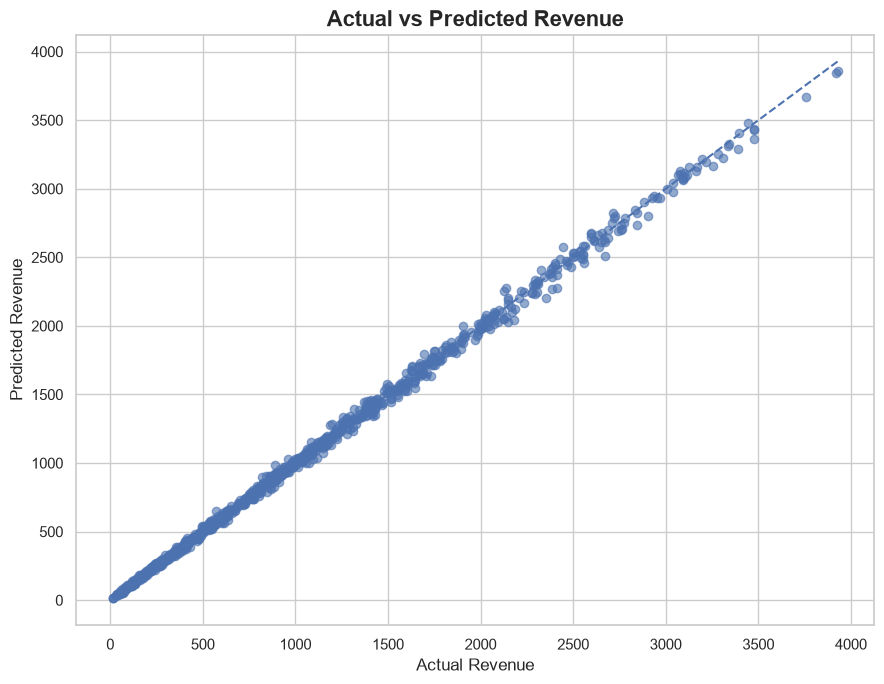

In [25]:
plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(
    "Actual vs Predicted Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.tight_layout()
plt.show()

## Residual Analysis

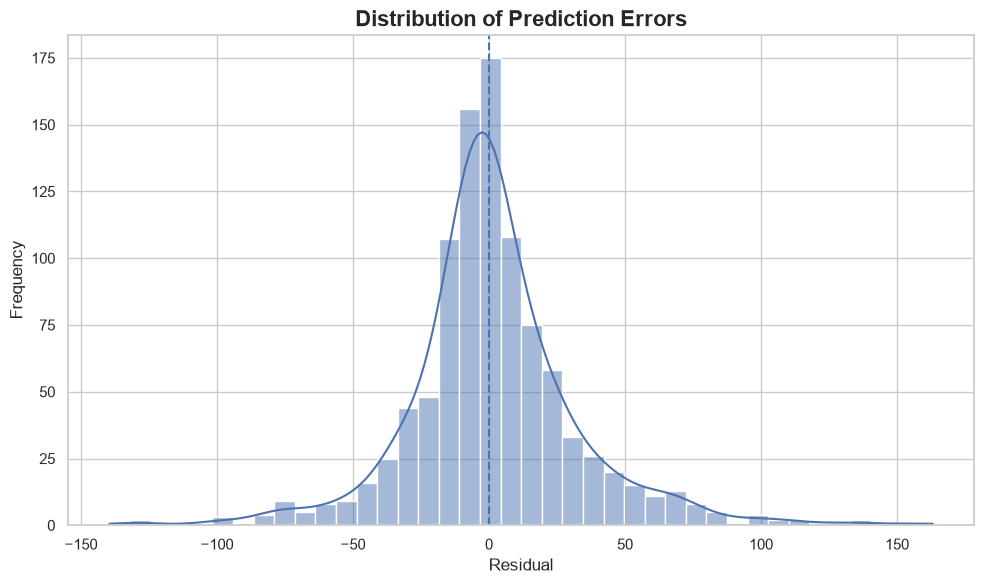

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of Prediction Errors",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Feature Importance

In [27]:
fitted_preprocessor = model.named_steps[
    "preprocessor"
]

encoded_features = (
    fitted_preprocessor
    .named_transformers_[
        "categorical"
    ]
    .get_feature_names_out(
        categorical_features
    )
)

feature_names = np.concatenate(
    [
        encoded_features,
        numeric_features
    ]
)

importances = (
    model
    .named_steps["regressor"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance.head(15)
)

,Feature,Importance
12,unit_price,0.484913
11,quantity,0.477905
13,discount,0.035337
15,customer_rating,0.000285
18,order_day,0.000276
16,order_year,0.000237
14,delivery_days,0.000211
17,order_month,0.000198
19,order_dayofweek,0.000174
9,payment_method_Card,0.000049


## Feature Importance Graph

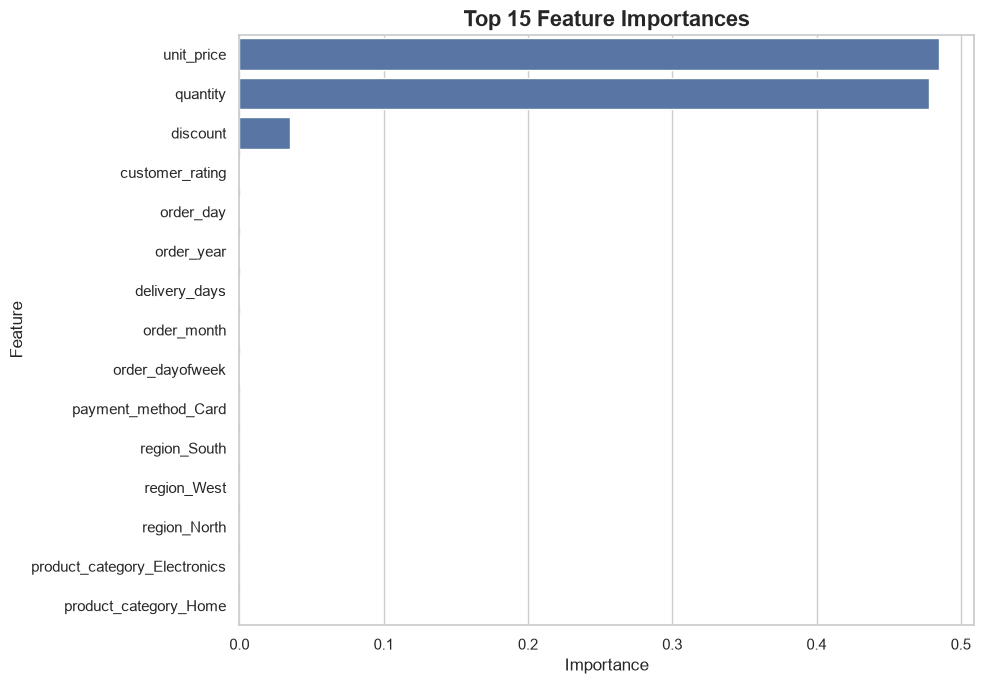

In [28]:

top_features = (
    feature_importance
    .head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Feature Importances",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# PART E — CROSS VALIDATION

In [29]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("5-Fold Cross Validation R² Scores:")

for i, score in enumerate(
    cv_scores,
    start=1
):
    print(
        f"Fold {i}: {score:.4f}"
    )

print(
    "\nMean CV R²:",
    cv_scores.mean()
)

print(
    "Standard Deviation:",
    cv_scores.std()
)

5-Fold Cross Validation R² Scores:
Fold 1: 0.9985
Fold 2: 0.9985
Fold 3: 0.9983
Fold 4: 0.9984
Fold 5: 0.9985

Mean CV R²: 0.9984524963391721
Standard Deviation: 6.755322915834978e-05


# PART F — FINAL BUSINESS INSIGHTS

In [30]:
print("=" * 60)
print("FINAL BUSINESS INSIGHTS")
print("=" * 60)

print(
    "\nTop Product Category:",
    category_revenue.idxmax()
)

print(
    "Top Region:",
    region_revenue.idxmax()
)

print(
    "Total Revenue:",
    f"{total_revenue:,.2f}"
)

print(
    "Average Order Revenue:",
    f"{average_revenue:,.2f}"
)

print(
    "Average Customer Rating:",
    f"{average_rating:.2f}"
)

print(
    "Average Discount:",
    f"{average_discount:.2%}"
)

print(
    "\nRandom Forest R²:",
    f"{r2:.4f}"
)

print(
    "Random Forest RMSE:",
    f"{rmse:.2f}"
)

FINAL BUSINESS INSIGHTS

Top Product Category: Electronics
Top Region: West
Total Revenue: 5,109,775.74
Average Order Revenue: 1,021.96
Average Customer Rating: 2.97
Average Discount: 18.00%

Random Forest R²: 0.9985
Random Forest RMSE: 31.66


# Strategic Recommendations

## 1. Category Strategy

Electronics was identified as the strongest product category in the descriptive analysis. Management should examine its revenue, order volume, pricing and profitability before increasing investment.

## 2. Regional Strategy

West was identified as the strongest region. The business should investigate the factors contributing to its performance and evaluate whether successful practices can be adapted to other regions.

## 3. Discount Strategy

The average discount was approximately 18%. Discounting should be optimized using revenue and profit impact rather than applying discounts uniformly.

## 4. Customer Experience

The average customer rating was approximately 2.97 out of 5. Customer experience should be investigated through delivery performance, product quality, service and returns.

## 5. Predictive Analytics

The Random Forest model provides a foundation for revenue prediction. Before business deployment, the model should be validated on future data and monitored regularly.

## 6. Continuous Data-Driven Decision Making

The organization should establish a recurring cycle of:

Data → Analysis → Insight → Action → Measurement → Improvement

# Limitations

1. The dataset contains 5,000 transactions and may not represent the complete e-commerce market.

2. Revenue does not represent profit because product costs and margins are not included.

3. Statistical relationships do not automatically imply causation.

4. The machine-learning model is based on historical data.

5. External variables such as competitors, economic conditions and marketing campaigns are not included.

6. Model performance may change when future customer behaviour changes.

7. More data and additional business features could improve the analysis.

# Conclusion

This Week 5 project integrates the complete data science workflow developed during the internship.

Week 2 focused on advanced visualization and data storytelling. Week 3 introduced statistical analysis and hypothesis testing, while Week 4 developed a machine-learning model for revenue prediction.

The final project combines descriptive, inferential and predictive analytics to transform e-commerce transaction data into actionable business insights.

The analysis highlights product category performance, regional performance, discount behaviour, customer experience and revenue prediction.

Future improvements can include additional business variables, advanced machine-learning models, hyperparameter tuning, time-based validation and interactive dashboards.

Overall, the project demonstrates how Python-based data science can support evidence-based business decision-making.

# Final Summary Table

In [31]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Unique Customers",
        "Average Order Revenue",
        "Average Customer Rating",
        "Average Discount",
        "Top Category",
        "Top Region",
        "Random Forest MAE",
        "Random Forest RMSE",
        "Random Forest R²",
        "Mean CV R²"
    ],
    "Value": [
        f"{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{average_revenue:,.2f}",
        f"{average_rating:.2f}",
        f"{average_discount:.2%}",
        category_revenue.idxmax(),
        region_revenue.idxmax(),
        f"{mae:.2f}",
        f"{rmse:.2f}",
        f"{r2:.4f}",
        f"{cv_scores.mean():.4f}"
    ]
})

display(final_summary)

,Metric,Value
0,Total Revenue,"5,109,775.74"
1,Total Orders,"5,000"
2,Unique Customers,989
3,Average Order Revenue,"1,021.96"
4,Average Customer Rating,2.97
5,Average Discount,18.00%
6,Top Category,Electronics
7,Top Region,West
8,Random Forest MAE,21.33
9,Random Forest RMSE,31.66
